# Sesión: 3 de marzo de 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
cars_df = pd.read_csv('cars_dataset.csv')

In [3]:
cars_df.head()

,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


In [4]:
# Se define la variable explicativa (X) y la variable respuesta (y)
X = cars_df[['speed']]
y = cars_df['dist']

Text(0, 0.5, 'Distancia')

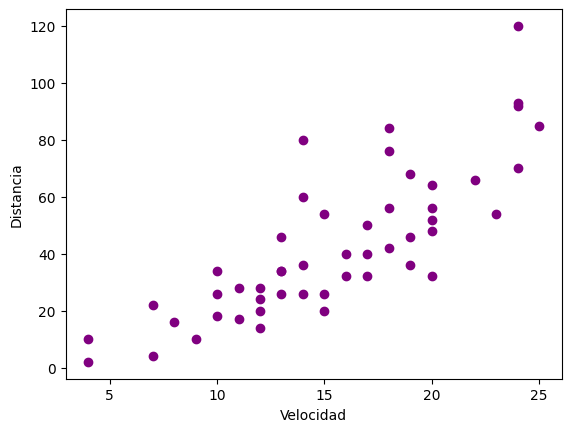

In [5]:
# Plot the actual data points
plt.scatter(X, y, color='purple')

plt.xlabel('Velocidad')
plt.ylabel('Distancia')

In [6]:
# Se divide los datos en train y test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Tamaño del training set: {X_train.shape[0]}")
print(f"Tamaño de testing set: {X_test.shape[0]}")

Tamaño del training set: 40
Tamaño de testing set: 10


In [7]:
# Se define que el modelo que se considerará es un modelo de regresión lineal
modelo = LinearRegression()

In [8]:
modelo

LinearRegression()

In [9]:
# Se entrena el modelo usando el training set
modelo.fit(X_train, y_train)

LinearRegression()

In [10]:
# Imprimir beta0 y beta1
print(f"Intercepto (beta0): {modelo.intercept_}")
print(f"Pendiente (beta1): {modelo.coef_}")

Intercepto (beta0): -14.133882307411135
Pendiente (beta1): [3.68568726]


In [11]:
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = modelo.predict(X_train)

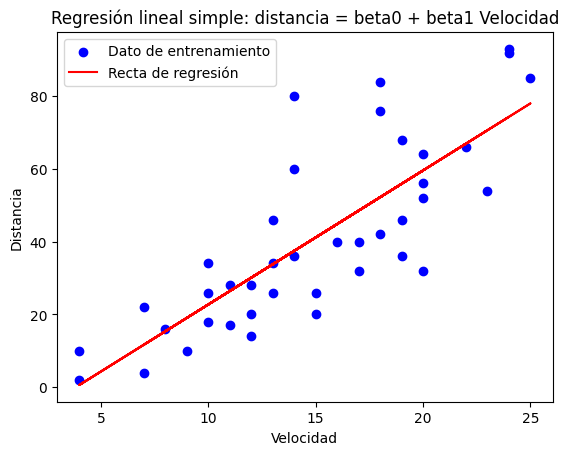

In [12]:
# Se grafican los datos de entrenamiento
plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')

# Se grafica la recta de regresión que predijo el modelo sobre el dataset de entrenamiento
plt.plot(X_train, y_pred_train, color='red', label='Recta de regresión')

# Se le agregan algunos adornos a la gráfica
plt.xlabel('Velocidad')
plt.ylabel('Distancia')
plt.title('Regresión lineal simple: distancia = beta0 + beta1 Velocidad')
plt.legend()
plt.show()

In [13]:
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_test = modelo.predict(X_test)

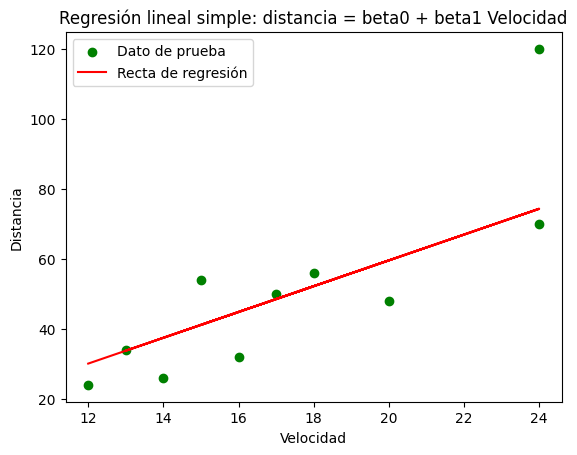

In [14]:
# Plot the actual data points
plt.scatter(X_test, y_test, color='green', label='Dato de prueba')

# Plot the regression line
plt.plot(X_test, y_pred_test, color='red', label='Recta de regresión')

# Add labels and title
plt.xlabel('Velocidad')
plt.ylabel('Distancia')
plt.title('Regresión lineal simple: distancia = beta0 + beta1 Velocidad')
plt.legend()
plt.show()

## Intentemos un segundo modelo

In [15]:
# Se define que el modelo que se considerará es un modelo de árbol de decisión
otro_modelo = DecisionTreeRegressor(max_depth = 4, random_state = 42)

In [16]:
otro_modelo

DecisionTreeRegressor(max_depth=4, random_state=42)

In [17]:
# Se entrena el modelo usando el training set
otro_modelo.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [18]:
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = otro_modelo.predict(X_train)

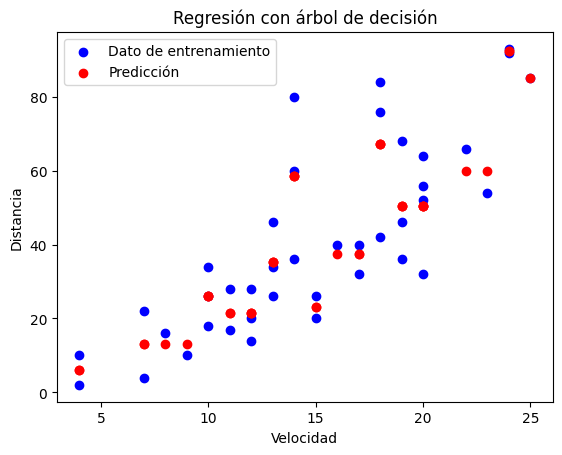

In [19]:
# Se grafican los datos de entrenamiento
plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')

# Se grafica la recta de regresión que predijo el modelo sobre el dataset de entrenamiento
plt.scatter(X_train, y_pred_train, color='red', label='Predicción')

# Se le agregan algunos adornos a la gráfica
plt.xlabel('Velocidad')
plt.ylabel('Distancia')
plt.title('Regresión con árbol de decisión')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


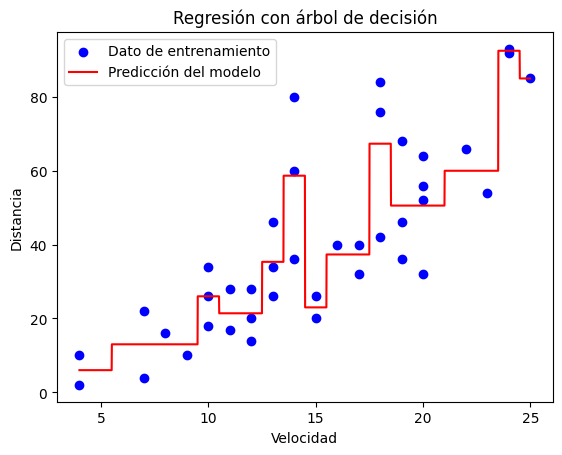

In [20]:
X_grid = np.arange(X.min().iloc[0], X.max().iloc[0], 0.01)[:, np.newaxis]
y_grid_pred = otro_modelo.predict(X_grid)

plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')
plt.plot(X_grid, y_grid_pred, color='red', label='Predicción del modelo')
plt.title("Regresión con árbol de decisión")
plt.xlabel("Velocidad")
plt.ylabel("Distancia")
plt.legend()
plt.show()

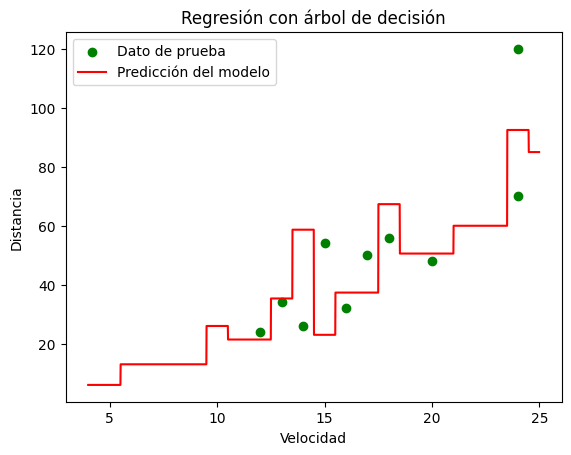

In [21]:
plt.scatter(X_test, y_test, color='green', label='Dato de prueba')
plt.plot(X_grid, y_grid_pred, color='red', label='Predicción del modelo')
plt.title("Regresión con árbol de decisión")
plt.xlabel("Velocidad")
plt.ylabel("Distancia")
plt.legend()
plt.show()

## Intentemos un tercer modelo

In [22]:
nuevo_modelo = DecisionTreeRegressor(max_depth = 2, random_state = 42)
# Se entrena el modelo usando el training set
nuevo_modelo.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [23]:
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = nuevo_modelo.predict(X_train)

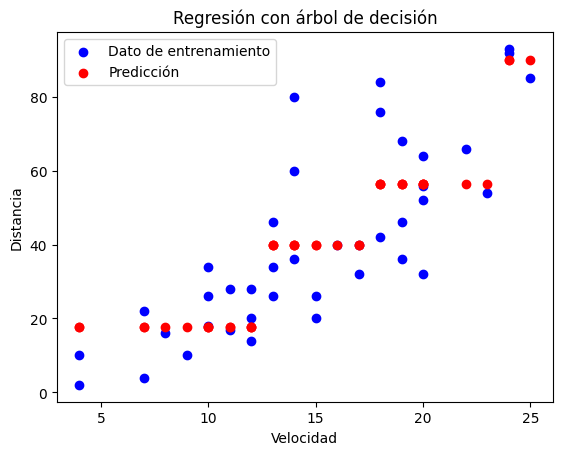

In [24]:
# Se grafican los datos de entrenamiento
plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')

# Se grafica la recta de regresión que predijo el modelo sobre el dataset de entrenamiento
plt.scatter(X_train, y_pred_train, color='red', label='Predicción')

# Se le agregan algunos adornos a la gráfica
plt.xlabel('Velocidad')
plt.ylabel('Distancia')
plt.title('Regresión con árbol de decisión')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


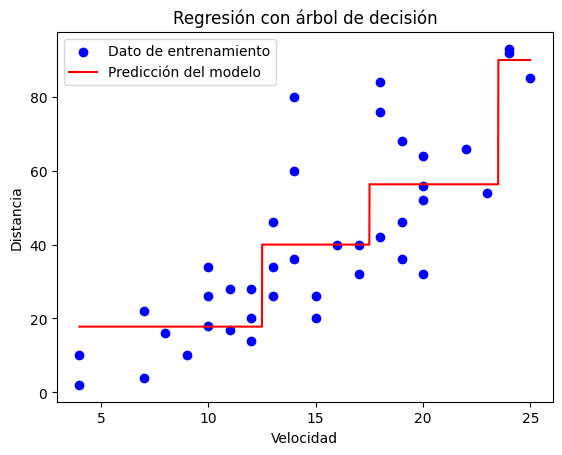

In [25]:
X_grid = np.arange(X.min().iloc[0], X.max().iloc[0], 0.01)[:, np.newaxis]
y_grid_pred = nuevo_modelo.predict(X_grid)

plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')
plt.plot(X_grid, y_grid_pred, color='red', label='Predicción del modelo')
plt.title("Regresión con árbol de decisión")
plt.xlabel("Velocidad")
plt.ylabel("Distancia")
plt.legend()
plt.show()

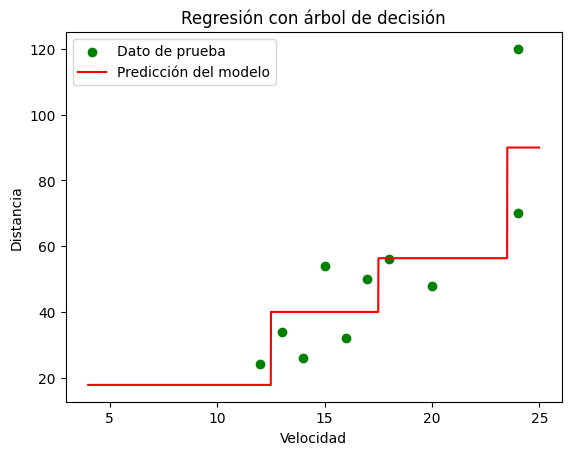

In [26]:
plt.scatter(X_test, y_test, color='green', label='Dato de prueba')
plt.plot(X_grid, y_grid_pred, color='red', label='Predicción del modelo')
plt.title("Regresión con árbol de decisión")
plt.xlabel("Velocidad")
plt.ylabel("Distancia")
plt.legend()
plt.show()

## Intentemos un cuarto modelo

In [27]:
modelo_bagging = BaggingRegressor(estimator = DecisionTreeRegressor(),
                                 n_estimators = 10,
                                 random_state = 42,
                                 bootstrap = True)

In [28]:
modelo_bagging

BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42)

In [29]:
modelo_bagging.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42)

In [30]:
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = modelo_bagging.predict(X_train)

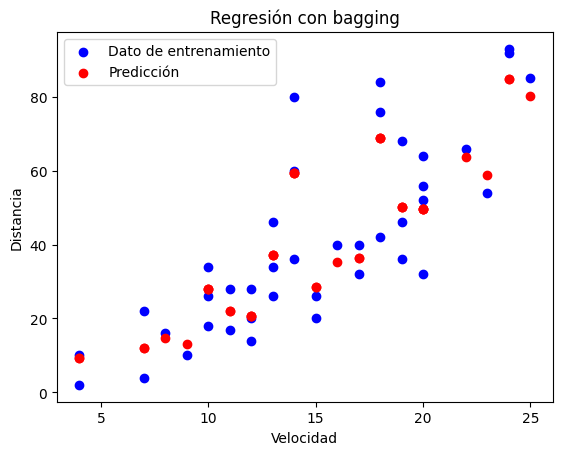

In [31]:
# Se grafican los datos de entrenamiento
plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')

# Se grafica la recta de regresión que predijo el modelo sobre el dataset de entrenamiento
plt.scatter(X_train, y_pred_train, color='red', label='Predicción')

# Se le agregan algunos adornos a la gráfica
plt.xlabel('Velocidad')
plt.ylabel('Distancia')
plt.title('Regresión con bagging')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


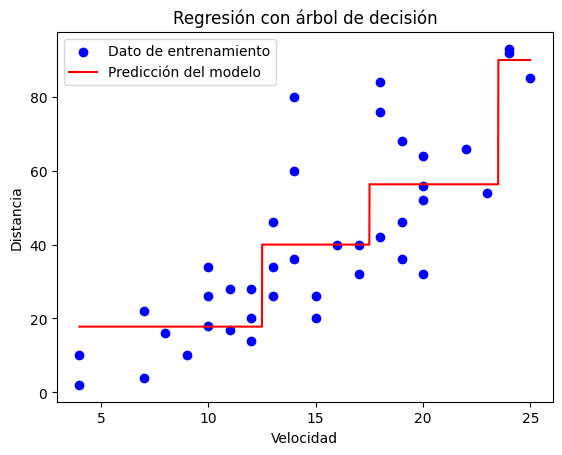

In [32]:
X_grid = np.arange(X.min().iloc[0], X.max().iloc[0], 0.01)[:, np.newaxis]
y_grid_pred = nuevo_modelo.predict(X_grid)

plt.scatter(X_train, y_train, color='blue', label='Dato de entrenamiento')
plt.plot(X_grid, y_grid_pred, color='red', label='Predicción del modelo')
plt.title("Regresión con árbol de decisión")
plt.xlabel("Velocidad")
plt.ylabel("Distancia")
plt.legend()
plt.show()

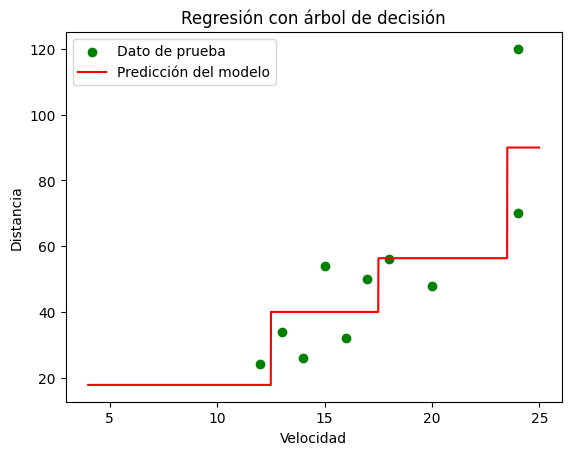

In [33]:
plt.scatter(X_test, y_test, color='green', label='Dato de prueba')
plt.plot(X_grid, y_grid_pred, color='red', label='Predicción del modelo')
plt.title("Regresión con árbol de decisión")
plt.xlabel("Velocidad")
plt.ylabel("Distancia")
plt.legend()
plt.show()

In [34]:
# Para el modelo de regresión lineal
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = modelo.predict(X_train)

# Podemos ver qué tal lo hizo en el dataset de prueba
y_pred_test = modelo.predict(X_test)

# Calculamos el error cuadrático medio
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Calculamos la raíz de error cuadrático medio
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

# Calculamos el MAPE
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"MSE en el dataset de entrenamiento: {mse_train}")
print(f"MSE en el dataset de prueba: {mse_test}")

print(f"RMSE en el dataset de entrenamiento: {rmse_train}")
print(f"RMSE en el dataset de prueba: {rmse_test}")

print(f"MAPE en el dataset de entrenamiento: {mape_train}")
print(f"MAPE en el dataset de prueba: {mape_test}")

MSE en el dataset de entrenamiento: 217.2225387542732
MSE en el dataset de prueba: 275.4289828774239
RMSE en el dataset de entrenamiento: 14.738471384586434
RMSE en el dataset de prueba: 16.596053231941138
MAPE en el dataset de entrenamiento: 0.3963323815557935
MAPE en el dataset de prueba: 0.21213804339012907


In [35]:
# Para el primer modelo de árbol
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = otro_modelo.predict(X_train)

# Podemos ver qué tal lo hizo en el dataset de prueba
y_pred_test = otro_modelo.predict(X_test)

# Calculamos el error cuadrático medio
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Calculamos la raíz de error cuadrático medio
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

# Calculamos el MAPE
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"MSE en el dataset de entrenamiento: {mse_train}")
print(f"MSE en el dataset de prueba: {mse_test}")

print(f"RMSE en el dataset de entrenamiento: {rmse_train}")
print(f"RMSE en el dataset de prueba: {rmse_test}")

print(f"MAPE en el dataset de entrenamiento: {mape_train}")
print(f"MAPE en el dataset de prueba: {mape_test}")

MSE en el dataset de entrenamiento: 97.45202380952381
MSE en el dataset de prueba: 362.3094467120181
RMSE en el dataset de entrenamiento: 9.871779161302374
RMSE en el dataset de prueba: 19.034427932355047
MAPE en el dataset de entrenamiento: 0.3118154284476976
MAPE en el dataset de prueba: 0.32045809691397925


In [36]:
# Para el primer modelo de árbol
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = nuevo_modelo.predict(X_train)

# Podemos ver qué tal lo hizo en el dataset de prueba
y_pred_test = nuevo_modelo.predict(X_test)

# Calculamos el error cuadrático medio
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Calculamos la raíz de error cuadrático medio
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

# Calculamos el MAPE
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"MSE en el dataset de entrenamiento: {mse_train}")
print(f"MSE en el dataset de prueba: {mse_test}")

print(f"RMSE en el dataset de entrenamiento: {rmse_train}")
print(f"RMSE en el dataset de prueba: {rmse_test}")

print(f"MAPE en el dataset de entrenamiento: {mape_train}")
print(f"MAPE en el dataset de prueba: {mape_test}")

MSE en el dataset de entrenamiento: 172.62559523809523
MSE en el dataset de prueba: 200.0172902494331
RMSE en el dataset de entrenamiento: 13.138705995572595
RMSE en el dataset de prueba: 14.142746913150681
MAPE en el dataset de entrenamiento: 0.5475486668545134
MAPE en el dataset de prueba: 0.23983977351624414


In [37]:
# Para el modelo de bagging
# Podemos ver qué tal lo hizo en el dataset de entrenamiento
y_pred_train = modelo_bagging.predict(X_train)

# Podemos ver qué tal lo hizo en el dataset de prueba
y_pred_test = modelo_bagging.predict(X_test)

# Calculamos el error cuadrático medio
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Calculamos la raíz de error cuadrático medio
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

# Calculamos el MAPE
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"MSE en el dataset de entrenamiento: {mse_train}")
print(f"MSE en el dataset de prueba: {mse_test}")

print(f"RMSE en el dataset de entrenamiento: {rmse_train}")
print(f"RMSE en el dataset de prueba: {rmse_test}")

print(f"MAPE en el dataset de entrenamiento: {mape_train}")
print(f"MAPE en el dataset de prueba: {mape_test}")

MSE en el dataset de entrenamiento: 102.83225928287982
MSE en el dataset de prueba: 361.84719514739226
RMSE en el dataset de entrenamiento: 10.140624205781409
RMSE en el dataset de prueba: 19.022281544215254
MAPE en el dataset de entrenamiento: 0.3527040758513348
MAPE en el dataset de prueba: 0.31382703200938494
